## Import library

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import optbinning
import pickle
import joblib
import shap

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")

from data_eda.data_eda import *
from data_eda.plot import * 
from features.features_eng import *
from models.model_training import *
from models.model_analysis import *
from utils.logger import *

## Read dataset

In [63]:
data_withbin = pd.read_csv("../data/predicted/data10K_Lending_Club_Loans_predicted_bin.csv")
data_withoutbin = pd.read_csv("../data/predicted/data10K_Lending_Club_Loans_predicted.csv")

In [64]:
print(data_withbin.shape)
data_withbin.head(5)

(10000, 14)


,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,loan_amnt_per_installment,income_to_interest_ratio,is_bad,prediction
0,0.149256,-0.584250,1.078203,0.810092,-0.019761,0.181547,-0.728222,0.140039,0.414956,0.279415,0.03658,0.245598,0,0.095670
1,-0.113627,-0.584250,-0.451049,-0.670379,-0.256405,0.181547,-0.064651,-0.131600,-0.076787,-0.263539,0.03658,-0.765318,0,0.372553
2,0.069937,0.274193,1.078203,0.810092,-0.019761,0.181547,0.327709,0.140039,0.414956,-0.175585,0.03658,0.245598,0,0.032019
3,-0.113627,-0.584250,0.274596,0.226565,-0.019761,0.181547,-0.064651,0.140039,0.175551,0.046724,0.03658,-0.457504,0,0.145895
4,-0.113627,0.274193,0.274596,0.226565,-0.019761,-0.175415,-0.064651,-0.131600,0.175551,0.046724,0.03658,-0.457504,0,0.125060


In [65]:
print(data_withoutbin.shape)
data_withoutbin.head(5)

(10000, 14)


,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio,prediction
0,4000,60 months,0.0729,A,50000.0,not verified,medical,0.0,12.1,44.0,0,50.150451,12.500000,0.095670
1,16000,60 months,0.1825,F,39216.0,not verified,debt_consolidation,2.0,64.0,5.0,0,39.169604,2.451000,0.372553
2,8700,36 months,0.0788,A,65000.0,not verified,credit_card,0.0,0.6,8.0,0,31.967665,7.471264,0.032019
3,18000,60 months,0.1149,B,57500.0,not verified,debt_consolidation,0.0,37.1,23.0,0,45.479812,3.194444,0.145895
4,16000,36 months,0.1183,B,50004.0,VERIFIED - income,debt_consolidation,4.0,40.4,21.0,0,30.180138,3.125250,0.125060


In [66]:
model = joblib.load("../data/artifacts/logistic_model.pkl")
feature = joblib.load("../data/artifacts/feature_use.pkl")

display(model)
print(feature)

LogisticRegression(C=0.5764922915002083, max_iter=2000, solver='liblinear')

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'annual_inc',
       'verification_status', 'purpose', 'inq_last_6mths', 'revol_util',
       'total_acc', 'loan_amnt_per_installment', 'income_to_interest_ratio'],
      dtype='object')


## Analysis

### SHAP


In [67]:
# explainer = shap.TreeExplainer(model)
explainer = shap.LinearExplainer(model, data_withbin.drop(columns = ['is_bad','prediction']))
shap_values = explainer.shap_values(data_withbin.drop(columns = ['is_bad','prediction']))

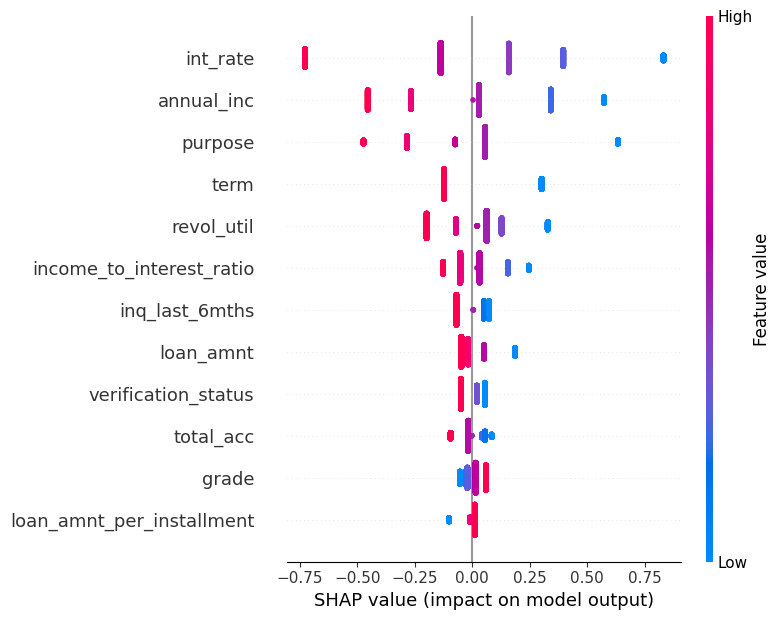

In [68]:
shap.summary_plot(shap_values, data_withbin.drop(columns = ['is_bad','prediction']))

## Bucketing

In [69]:
bucketing = data_withbin[['is_bad','prediction']]

bucketing.head(5)

,is_bad,prediction
0,0,0.095670
1,0,0.372553
2,0,0.032019
3,0,0.145895
4,0,0.125060


In [70]:
binning_process, iv_summary = iv_score(bucketing[['prediction']]
                                        , bucketing['is_bad']
                                        , max_n_bins=10
                                        , min_n_bins=10
                                        , min_bin_size=0.05)

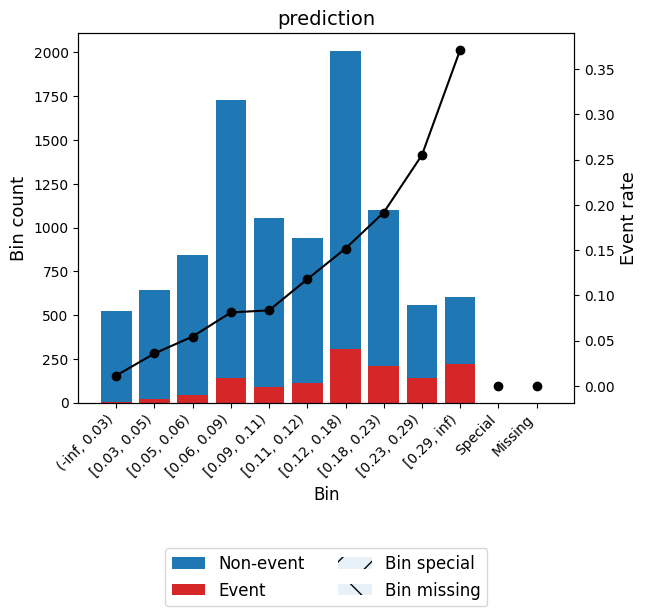

In [71]:
build = binning_process.get_binned_variable('prediction')
bin_df = build.binning_table.build(); bin_df
build.binning_table.plot(metric = 'event_rate', show_bin_labels=True)

In [72]:
bin_df

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.03)",523,0.0523,517,6,0.011472,2.550897,0.139682,0.013875
1,"[0.03, 0.05)",642,0.0642,619,23,0.035826,1.387224,0.074006,0.008574
2,"[0.05, 0.06)",843,0.0843,797,46,0.054567,0.946826,0.053056,0.006395
3,"[0.06, 0.09)",1726,0.1726,1586,140,0.081112,0.521941,0.038669,0.004779
4,"[0.09, 0.11)",1054,0.1054,966,88,0.083491,0.49044,0.021097,0.002611
5,"[0.11, 0.12)",942,0.0942,831,111,0.117834,0.107713,0.001050,0.000131
6,"[0.12, 0.18)",2010,0.2010,1705,305,0.151741,-0.184378,0.007312,0.000913
7,"[0.18, 0.23)",1102,0.1102,891,211,0.191470,-0.464901,0.028163,0.003489
8,"[0.23, 0.29)",557,0.0557,415,142,0.254937,-0.832935,0.051624,0.006273
9,"[0.29, inf)",601,0.0601,378,223,0.371048,-1.377664,0.177412,0.020574


## Scorecard

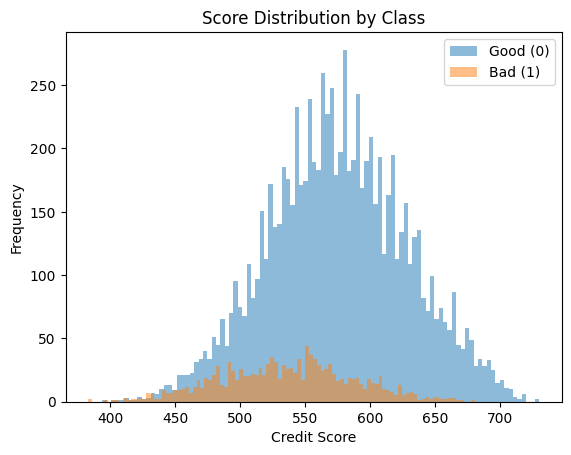

In [73]:
def calculate_score(prob,
                    base_score=700,
                    base_odds=50,
                    pdo=50):
    """
    Convert probability of default into credit score.

    Parameters
    ----------
    prob : float or np.array
        Probability of default (model output)
    base_score : int
        Score corresponding to base odds
    base_odds : float
        Odds of good:bad at base score
    pdo : int
        Points to double the odds

    Returns
    -------
    score : float or np.array
        Credit score
    """

    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)

    odds = (1 - prob) / prob

    score = offset + factor * np.log(odds)

    return np.round(score, 0)

data_withbin['scorecard'] = data_withbin['prediction'].apply(lambda x: calculate_score(x))

# separate classes
good = data_withbin[data_withbin["is_bad"] == 0]["scorecard"]
bad = data_withbin[data_withbin["is_bad"] == 1]["scorecard"]

plt.figure()

plt.hist(good, bins=100, alpha=0.5, label="Good (0)")
plt.hist(bad, bins=100, alpha=0.5, label="Bad (1)")

plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Score Distribution by Class")
plt.legend()

plt.show()